In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import poisson,nbinom
import matplotlib.pyplot as plt
import os
import matplotlib as mpl
from matplotlib.patches import Rectangle
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.colors import LinearSegmentedColormap

In [2]:
def histogram_ini(data,fit_parameters,xlim,ylim,ax,line_width):

    
    initial_cells=np.arange(0,np.max(data)+1,dtype=int)
    bin_count=np.bincount(data)
    total_samples=np.sum(bin_count)
        
    ax.bar(initial_cells,bin_count/np.sum(bin_count),color='#7ac2f4')
    ax.errorbar(initial_cells,bin_count/total_samples,np.sqrt(bin_count/total_samples**2) * (1-bin_count/total_samples),elinewidth=2,fmt='None',ecolor='#359fe8',zorder=4)

    ax.plot(initial_cells, poisson.pmf(initial_cells,fit_parameters.lam),color='#8b63ed',lw=line_width , label='Poisson')
    ax.plot(initial_cells, nbinom.pmf(initial_cells,fit_parameters.r_like,fit_parameters.r_like/(fit_parameters.r_like+fit_parameters.lam)), color='#ad053f',lw=line_width , label='Negative binomial')
 

    ax.set_xlim([-0.4,xlim])
    ax.set_ylim([0,ylim])
     

def n_final_cum_plot(df,xlim,ax,colors,line_width,title):
    
    ax.plot([-100,400],[1,1],'gray',linewidth=1)
    concentration=df.concentration.unique()
    plt_handles=[]
    for c,j in enumerate(concentration):
        foo=ax.ecdf(df[df.concentration==j].n_cells_final.values,color=colors[c],label=f'{np.round(concentration[c],2)}',linewidth=line_width)
        plt_handles.append(foo)
    
    xticks=np.arange(0,400,20)
    ax.set_xticks(xticks)
    ax.set_xticklabels([0]+[np.round(x,2) if i%2  else '' for i,x in enumerate(xticks[1:])])

    ax.set_ylim([0,1.05])
    ax.set_xlim(xlim)
    ax.set_xlabel('')    
    ax.set_ylabel('')  

    legend1=ax.legend(handles= plt_handles,frameon=False,fancybox=True,handlelength=1.5,title=title,loc='lower right',bbox_transform=ax.transAxes,ncols=2)
    ax.add_artist(legend1)

    

def initial_final_plot(ax,data,threshold,xlim,ylim,marker_size,lw):
    
    colors=sns.color_palette("colorblind")
    
    ax.plot([-1,100],[threshold,threshold],linewidth=lw,color='gray',linestyle='--',zorder=0)
    sns.scatterplot(data=data,x='n_cells',y='n_cells_final',s=marker_size,ax=ax)
        
    yticks=np.arange(0,360,20)   
    yticklabels=[]

    for i,y in enumerate(yticks):
        if(i%2):
            yticklabels.append('')
        else:
              yticklabels.append(y)
    ax.set_yticks(yticks)   
    ax.set_yticklabels(yticklabels)
    ax.set_xlabel('')    
    ax.set_ylabel('')    
    
    xticks=np.arange(0,100,1)   
    xticklabels=[]
    
    
    for i,y in enumerate(xticks):
        if(i%2):
            xticklabels.append('')
        else:
              xticklabels.append(y)
    ax.set_xticks(xticks)   
    ax.set_xticklabels(xticklabels)    
            

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

# Load Data 

In [17]:
Genta = pd.read_csv(f'Tables/Gentamicin_measured.csv',index_col=0)
Genta_fit=pd.read_csv(f'Tables/Gentamicin_ini_fit.csv',index_col=0)
Genta_threshold=[20,20,40,40]

Tetra = pd.read_csv(f'Tables/Tetracycline_measured.csv',index_col=0)
Tetra_threshold=[20,20,20,20]


Chp = pd.read_csv(f'Tables/Chloramphenicol_measured.csv',index_col=0)
Chp_threshold=[40,20,30,20,20,20,30,20,30,30,40,20,40,20]

Cipro = pd.read_csv(f'Tables/Ciprofloxacin_measured.csv',index_col=0)
Cipro_threshold=[20,20,20,20]

In [18]:
Genta.drop(Genta[Genta.trash].index,inplace=True)
Tetra.drop(Tetra[Tetra.trash].index,inplace=True)
Chp.drop(Chp[Chp.trash].index,inplace=True)
Cipro.drop(Cipro[Cipro.trash].index,inplace=True)


for d,t in enumerate(Genta_threshold):
    Genta.drop(Genta[(Genta.dataset==d) & (Genta.n_cells)>Genta_threshold[d]].index,inplace=True)

for d,t in enumerate(Tetra_threshold):
    Tetra.drop(Tetra[(Tetra.dataset==d) & (Tetra.n_cells)>Tetra_threshold[d]].index,inplace=True)
    
for d,t in enumerate(Chp_threshold):
    Chp.drop(Chp[(Chp.dataset==d) & (Chp.n_cells)>Chp_threshold[d]].index,inplace=True)
    
for d,t in enumerate(Cipro_threshold):
    Cipro.drop(Cipro[(Cipro.dataset==d) & (Cipro.n_cells)>Cipro_threshold[d]].index,inplace=True)

# Plot

In [19]:
tex_fonts = {
    # Use LaTeX to write all text
    "text.usetex": True,
    "font.family": "serif",
    # Use 10pt font in plots, to match 10pt font in document
    "axes.labelsize": 10,
    "font.size": 10,
    # Make the legend/label fonts a little smaller
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
}
tickParams = {
    "xtick.top":True,
    "xtick.bottom":True,
    "xtick.direction": "in",
    "ytick.left":True,
    "ytick.right":True,
    "ytick.direction": "in",
}
spinesParams = {
    'axes.spines.right' : True,
    'axes.spines.top' : True
}
plt.rcParams.update(tex_fonts)
plt.rcParams.update(tickParams)
inchPerCm = 0.393701
goldenRatio = (1+np.sqrt(5))/2
figWidthCm = 17.9
#figHeightCm = figWidthCm
figHeightCm = figWidthCm*1.2

figWidthInches = figWidthCm*inchPerCm
figHeightInches = figHeightCm*inchPerCm



lw=1
marker_size=10
lw2=1

fig_label_x=-0.15
fig_label_y=1.05

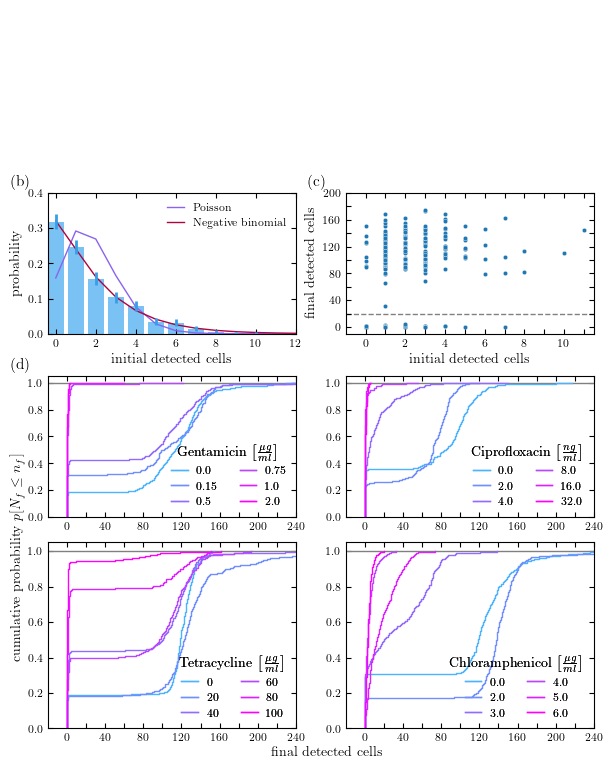

In [20]:
# Figure 3 plot
fig = plt.figure(figsize=(figWidthInches, figHeightInches))

# First three rows with normal spacing
gs1 = gridspec.GridSpec(3, 2, top=0.9, bottom=0.3, hspace=0.3,figure=fig,)

# Last row positioned closer to the third row
gs2 = gridspec.GridSpec(1, 2, top=0.27, bottom=0.05,figure=fig,)

# Create subplots
axes_list = []

# First three rows
for i in range(3):
    for j in range(2):
        ax = fig.add_subplot(gs1[i, j])
        axes_list.append(ax)

# Last row (closer to the row above)
for j in range(2):
    ax = fig.add_subplot(gs2[0, j])
    axes_list.append(ax)

ax = np.array(axes_list).reshape(4, 2)
    

ax[0,0].set_axis_off()
ax[0,1].set_axis_off()

#--------initial condition ----------------


histogram_ini(Genta[(Genta.dataset==2) & (Genta.concentration==0.5)].n_cells.values,Genta_fit[(Genta_fit.dataset==2) & (Genta_fit.concentration==0.5)],12,0.4,ax[1,0],lw)

ax[1,0].legend(frameon=False,fancybox=True,handlelength=1.5)


#------------final histogram condition on selected initial cell number

initial_final_plot(ax[1,1],Genta[(Genta.dataset==0) & (Genta.concentration==0.5)],20,[-1,11.5],[-10,200],marker_size,lw)


#---------- Cumulatative plots for final cell number -------------------

xlim=[-20,240]

lw=1

#hist_colors=sns.color_palette()
cmap = mpl.colormaps['cool']
cmap = LinearSegmentedColormap.from_list(
    'YlOrBr_dark',
    cmap(np.linspace(0.3, 1.0, 256))
)


hist_colors_Genta = cmap(np.linspace(0, 1, 6))
hist_colors_Cipro = cmap(np.linspace(0, 1, 6))
hist_colors_Tetra = cmap(np.linspace(0, 1, 6))
hist_colors_Chp = cmap(np.linspace(0, 1, 6))



n_final_cum_plot(Genta[Genta.dataset==0],xlim,ax[2,0],hist_colors_Genta,lw,r'Gentamicin $\left[\frac{\mu g}{ml}\right]$')
n_final_cum_plot(Cipro[Cipro.dataset==0],xlim,ax[2,1],hist_colors_Cipro,lw,r'Ciprofloxacin $\left[\frac{ng}{ml}\right]$')
n_final_cum_plot(Tetra[Tetra.dataset==0],xlim,ax[3,0],hist_colors_Tetra,lw,r'Tetracycline $\left[\frac{\mu g}{ml}\right]$')
n_final_cum_plot(Chp[Chp.dataset==5],xlim,ax[3,1],hist_colors_Chp,lw,r'Chloramphenicol $\left[\frac{\mu g}{ml}\right]$')



#----------Set axis-------------------


ax[0,0].set_ylabel('')
ax[0,0].set_xlabel('')

ax[0,1].set_ylabel('')
ax[0,1].set_xlabel('')

ax[1,0].set_xlabel('initial detected cells')
ax[1,0].set_ylabel('probability')



ax[1,1].set_ylabel('final detected cells')
ax[1,1].set_xlabel('initial detected cells')

ax[2,0].set_ylabel('')
ax[2,0].set_xlabel('')

ax[2,1].set_ylabel('')
ax[2,1].set_xlabel('')



#ax[0,0].text(fig_label_x, fig_label_y, '(a)', transform=ax[0,0].transAxes,
 #           size=11)
ax[1,0].text(fig_label_x, fig_label_y, '(b)', transform=ax[1,0].transAxes,
            size=11)
ax[1,1].text(fig_label_x, fig_label_y, '(c)', transform=ax[1,1].transAxes,
            size=11)

ax[2,0].text(fig_label_x, fig_label_y, '(d)', transform=ax[2,0].transAxes,
            size=11)

#plt.tight_layout(w_pad=0.1,h_pad=0.1)

ax[2,0].text(fig_label_x, -1, r'cumulative probability $p[N_f\le$ $n_f]$', transform=ax[2,0].transAxes,rotation=90)
ax[3,0].text(0.9,-0.15, 'final detected cells', transform=ax[3,0].transAxes)

#plt.subplots_adjust(left=0.07,bottom=0.07)
plt.show()

In [14]:
baseSavePath=''
saveFigPath = os.path.join(baseSavePath,'Figure3_pre.pdf')
fig.savefig(saveFigPath,bbox_inches='tight', pad_inches=0.05)